## Chapter 8: Distilling Reasoning Models for Efficient Reasoning

In [12]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.16
torch version: 2.10.0
tokenizers version: 0.22.2


In [13]:
import json
import requests
from pathlib import Path


def load_distill_data(
    local_path=None,
    partition="deepseek-r1-math-train",
    save_copy=True,
):

    if local_path is None:
        local_path = f"{partition}.json"
    local_path = Path(local_path)

    url = (
        "https://huggingface.co/datasets/rasbt/math_distill"
        "/resolve/main/data/"
        f"{partition}.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        f"MATH/{partition}.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB (cached)")
        return data

    assert partition in (
        "deepseek-r1-math-train",
        "deepseek-r1-math500",
        "qwen3-235b-a22b-math-train",
        "qwen3-235b-a22b-math500",
    )

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
    except requests.RequestException:
        print("Using backup URL.")
        r = requests.get(backup_url, timeout=30)
        r.raise_for_status()

    data = r.json()

    if save_copy:
        with local_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB")

    return data

In [14]:
math_train = load_distill_data(partition="deepseek-r1-math-train")

print("Dataset size:", len(math_train))

deepseek-r1-math-train.json: 107538.0 KB (cached)
Dataset size: 12000


In [15]:
from pprint import pprint

pprint(math_train[4])

{'gtruth_answer': '6',
 'message_content': 'Sam worked \\( x \\) days and did not work \\( y \\) '
                    'days. We know:\n'
                    '\\[\n'
                    'x + y = 20\n'
                    '\\]\n'
                    'His total earnings are calculated as:\n'
                    '\\[\n'
                    '60x - 30y = 660\n'
                    '\\]\n'
                    'Substituting \\( x = 20 - y \\) into the earnings '
                    'equation:\n'
                    '\\[\n'
                    '60(20 - y) - 30y = 660\n'
                    '\\]\n'
                    'Simplifying:\n'
                    '\\[\n'
                    '1200 - 60y - 30y = 660 \\\\\n'
                    '1200 - 90y = 660 \\\\\n'
                    '-90y = 660 - 1200 \\\\\n'
                    '-90y = -540 \\\\\n'
                    'y = \\frac{-540}{-90} = 6\n'
                    '\\]\n'
                    'Sam did not work \\(\\boxed{6}\\) days.',
 'message_t

In [16]:
math_train[4].keys()

dict_keys(['problem', 'gtruth_answer', 'message_thinking', 'message_content'])

In [17]:
def format_distilled_answer(entry):
    content = str(entry["message_content"]).strip()
    if not content:
        raise ValueError("Missing non-empty 'message_content' field.")
    thinking = str(entry["message_thinking"]).strip()
    return f"<think>{thinking}</think>\n\n{content}"

In [18]:
print(format_distilled_answer(math_train[4]))

<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? Is it that he loses $30 per day not worked from his total earnings?

Wait, maybe. So if he didn't work y days, then he loses 30*y dollars. But wait, does he get a base salary and then deductions? Or is his total earnings 60x minus 30y?

The problem says, "On days that he works, he earns $60. For each day that he does not work, $30 is subtracted from his earnings." So probably, his total earnings are calculated by 60

In [19]:
from reasoning_from_scratch.ch07 import download_from_github

_ = download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_json.py"
)

evaluate_json.py: 3.3 KB (cached)


In [20]:
!uv run evaluate_json.py \
--json_path "deepseek-r1-math-train.json" \
--gtruth_answer gtruth_answer \
--generated_text message_content

Accuracy: 90.6% (10871/12000)


In [21]:
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer
)

def load_reasoning_tokenizer(local_dir="qwen3"):
    download_qwen3_small(
        kind="reasoning", tokenizer_only=True, out_dir=local_dir
    )

    tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_path,
        apply_chat_template=True,
        add_generation_prompt=True,
        add_thinking=True,
    )
    
    return tokenizer


tokenizer = load_reasoning_tokenizer()

✓ qwen3/tokenizer-reasoning.json already up-to-date


In [22]:
prompt = "Sam is hired for a 20-day period..."

prompt_ids = tokenizer.encode(prompt)
decoded_prompt = tokenizer.decode(prompt_ids)
print(decoded_prompt)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant



In [23]:
answer = (
    "<think>Okay, let me try to solve "
    "this problem...</think> \\boxed{4}"
)
answer_ids = tokenizer.encode(answer, chat_wrapped=False)
decoded_answer = tokenizer.decode(answer_ids)
print(decoded_answer)

<think>Okay, let me try to solve this problem...</think> \boxed{4}


In [24]:
token_ids = prompt_ids + answer_ids + [tokenizer.eos_token_id]
decoded_token_ids = tokenizer.decode(token_ids)
print(decoded_token_ids)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant
<think>Okay, let me try to solve this problem...</think> \boxed{4}<|im_end|>


In [25]:
from reasoning_from_scratch.ch03 import render_prompt

def build_examples(data, tokenizer):
    examples = []
    skipped = 0

    for entry in data:
        try:
            prompt = render_prompt(entry["problem"])
            prompt_ids = tokenizer.encode(prompt)
    
            target_answer = format_distilled_answer(entry)
            answer_ids = tokenizer.encode(
                target_answer, chat_wrapped = False
            )

            token_ids = (
                prompt_ids + answer_ids + [tokenizer.eos_token_id]
            )

            if len(token_ids) < 2:
                skipped += 1
                continue
            examples.append({
                "token_ids": token_ids,
                "prompt_len": len(prompt_ids),
            })
        except (KeyError, TypeError, ValueError):
            skipped += 1
    return examples, skipped

In [26]:
examples, skipped = build_examples(math_train, tokenizer)

print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

Number of examples: 12000
Number of skipped examples: 0


In [27]:
print(tokenizer.decode(examples[4]["token_ids"]))

<|im_start|>user
You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work?

Answer:<|im_end|>
<|im_start|>assistant
<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? I

In [28]:
def compute_length(examples, answer_only=False):
    lengths = []
    for ex in examples:
        total = len(ex["token_ids"])
        length = total - ex["prompt_len"] if answer_only else total
        lengths.append(length)
    avg_len = round(sum(lengths) / len(lengths))

    shortest_len = min(lengths)
    longest_len = max(lengths)
    shortest_idx = lengths.index(shortest_len)
    longest_idx = lengths.index(longest_len)

    print(f"Average: {avg_len} tokens")
    print(f"Shortest: {shortest_len} tokens (index {shortest_idx})")
    print(f"Longest: {longest_len} tokens (index {longest_idx})")

compute_length(examples)


Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)


In [29]:
def filter_examples_by_max_len(examples, max_len=2048):
    filtered_examples = [
        s for s in examples
        if len(s["token_ids"]) <= max_len
    ]

    print("Original:", len(examples))
    print("Filtered:", len(filtered_examples))
    print("Removed:", len(examples) - len(filtered_examples))

    return filtered_examples

filtered_examples = filter_examples_by_max_len(examples, max_len=2048)

Original: 12000
Filtered: 6695
Removed: 5305


In [30]:
compute_length(filtered_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


In [31]:
import random

rng = random.Random(123)
rng.shuffle(filtered_examples)

train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]

In [32]:
print("Number of train examples:", len(train_examples))
print("Number of validation examples:", len(val_examples))

Number of train examples: 6670
Number of validation examples: 25


In [33]:
compute_length(train_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [34]:
compute_length(val_examples)

Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


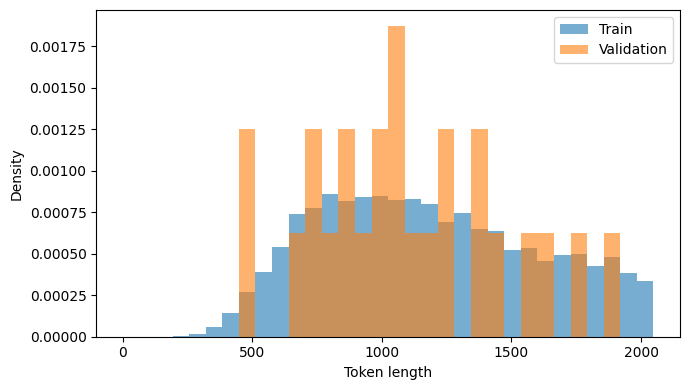

In [35]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
import torch

from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()

model, _ = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [37]:
token_ids = train_examples[5730]["token_ids"]
prompt_len = train_examples[5730]["prompt_len"]

In [38]:
from reasoning_from_scratch.ch06 import sequence_logprob

tok = torch.tensor(token_ids, dtype=torch.long, device=device)

with torch.no_grad():
    seq_logprob = sequence_logprob(model, tok, prompt_len)
    num_answer_tokens = tok.numel() - prompt_len
    avg_logprob = -seq_logprob / num_answer_tokens
print(f"Average logprob: {avg_logprob:.2f}")

Average logprob: 1.69


In [39]:
input_ids = tok[:-1].unsqueeze(0)
target_ids = tok[1:]
logits = model(input_ids).squeeze(0)

first_answer_logit_idx = max(prompt_len - 1, 0)
answer_logits = logits[first_answer_logit_idx:]
answer_targets = target_ids[first_answer_logit_idx:]

with torch.no_grad():
    ce_mean_direct = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
print(f"Cross-entropy: {ce_mean_direct:.2f}")

Cross-entropy: 1.69


In [40]:
def compute_example_loss(model, example, device):
    token_ids = example["token_ids"]
    prompt_len = example["prompt_len"]

    input_ids = torch.tensor(
        token_ids[:-1], dtype=torch.long, device=device
    ).unsqueeze(0)

    target_ids = torch.tensor(
       token_ids[1:], dtype=torch.long, device=device
    )

    logits = model(input_ids).squeeze(0)
    answer_start = max(prompt_len - 1, 0)
    answer_logits = logits[answer_start:]
    answer_targets = target_ids[answer_start:] 

    loss = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
    return loss

In [41]:
with torch.no_grad():
    loss = compute_example_loss(
        model, train_examples[5730], device
    )
print(f"Loss: {loss:.2f}")

Loss: 1.69


In [42]:
@torch.no_grad()
def evaluate_examples(model, examples, device):
    was_training = model.training
    model.eval()
    total_loss = 0.0
    num_examples = 0

    for example in examples:
        loss = compute_example_loss(model, example, device)
        total_loss += loss.item()
        num_examples += 1
    if was_training:
        model.train()
    return total_loss / num_examples

In [43]:
train_loss = evaluate_examples(model, train_examples[:3], device)
print(f"Train loss (3 examples): {train_loss:.2f}")

Train loss (3 examples): 0.98


In [44]:
val_loss = evaluate_examples(model, val_examples[:3], device)
print(f"Validation loss (3 examples): {val_loss:.2f}")

Validation loss (3 examples): 1.02


In [47]:
import time

def train_distillation(
    model,
    train_examples,
    val_examples,
    device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=None,
    seed=123,
    log_every=50,
    checkpoint_dir="checkpoints",
    csv_log_path=None,
):
    # step 1: initize the optimizer 
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()

    total_steps = epochs * len(train_examples)
    global_step = 0

    rng = random.Random(seed)

    if csv_log_path is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        csv_log_path = f"train_distill_metrics_{timestamp}.csv"
    csv_log_path = Path(csv_log_path)

    # step 2 :iterate training epochs

    for epoch in range(1, epochs + 1):
        # step 3: shuffle the training examples at the start of the epoch
        epoch_examples = list(train_examples)
        rng.shuffle(epoch_examples)

        # step 4: iterate over training examples in epoch
        for example in epoch_examples:
            global_step += 1

            # step 5: reset loss to zero
            optimizer.zero_grad()

            # step 6: compute the loss
            loss = compute_example_loss(model, example, device)

            # step 7: backward the gradients
            loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), grad_clip_norm
                )

            # step 8: update the model weights
            optimizer.step()

            # step 9: periodically evaluate the current model on the validation set
            if log_every and global_step % log_every == 0:
                val_loss = evaluate_examples(
                    model=model,
                    examples=val_examples,
                    device=device
                )
                model.train()
                print(
                    f"[Epoch {epoch}/{epochs} "
                    f"Step {global_step}/{total_steps}] "
                    f"train_loss={loss.item():.4f} "
                    f"val_loss={val_loss:.4f}"
                )
                append_csv_metrics(
                    csv_log_path=csv_log_path,
                    epoch_idx=epoch,
                    total_steps=global_step,
                    train_loss=loss.item(),
                    val_loss=val_loss,
                )
        # step 10 : save a ckpt for this epoch
        ckpt_path = save_checkpoint(
            model=model,
            checkpoint_dir=checkpoint_dir,
            step=global_step,
            suffix=f"epoch{epoch}",
        )
        print(f"Saved checkpoint to {ckpt_path}")
    return model

def save_checkpoint(model, checkpoint_dir, step, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-distill-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path

def append_csv_metrics(
    csv_log_path,
    epoch_idx,
    total_steps,
    train_loss,
    val_loss,
):
    if not csv_log_path.exists():
        csv_log_path.write_text(
            "epoch,total_steps,train_loss,val_loss\n",
            encoding="utf-8",
        )
    with csv_log_path.open("a", encoding="utf-8") as f:
        f.write(
            f"{epoch_idx},{total_steps},{train_loss:.6f},"
            f"{val_loss:.6f}\n"
        )

In [46]:
torch.manual_seed(123)

train_distillation(
    model,
    train_examples=train_examples[:10],
    val_examples=val_examples[:10],
    device=device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=1.0,
    seed=123,
    log_every=5,
    csv_log_path="train_distill_mertrics.csv"
)

KeyboardInterrupt: 

In [48]:
download_from_github(
    "ch08/04_train_with_distillation/distill.py"
)

distill.py: 14.6 KB


In [50]:
download_from_github(
    "ch08/03_logs/deepseek-r1-2048_distill_metrics.csv"
)

deepseek-r1-2048_distill_metrics.csv: 10.3 KB


In [ ]:
import csv
import matplotlib.pyplot as plt

def plot_distill_metrics(csv_path="train_distill_metrics.csv"):
    total_steps, train_losses, val_losses, epoch_bounds = [], [], [], {}

    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            step = int(row["total_steps"])
            epoch = int(row["epoch"])
            total_steps.append(step)
            train_losses.append(float(row["train_loss"]))
            val_losses.append(float(row["val_loss"]))
            epoch_bounds.setdefault(epoch, [step, step])[1] = step  # first/last step for each epoch

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(total_steps, train_losses, label="train_loss", alpha=0.3)
    ax.plot(total_steps, val_losses, label="val_loss")
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Loss")
    ax.legend()

    # Epoch axis
    epoch_axis = ax.secondary_xaxis("bottom")
    epoch_axis.spines["bottom"].set_position(("outward", 45))
    epochs = sorted(epoch_bounds)
    epoch_axis.set_xticks(
        [(epoch_bounds[epoch][0] + epoch_bounds[epoch][1]) / 2 
          for epoch in epochs]
    )
    epoch_axis.set_xticklabels(epochs)
    epoch_axis.set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

plot_distill_metrics("deepseek-r1-2048_distill_metrics.csv")